# 🌙 Indirect Sleep Quality Estimation
## Integrated Multi-Source Data Analytics & Predictive Modelling

---

| Item | Detail |
|:--|:--|
| **Author** | Peraya Leangsongchai |
| **Data Sources** | KidBright IoT sensors · Google Forms logs · OpenWeatherMap · IQAir · Sunrise-Sunset API · Free Astro API |
| **ML Approach** | Leave-One-Out Cross-Validation (KNN, Decision Tree, XGBoost) |
| **Target** | Morning mood score (1–5 Likert scale) |

### Notebook Outline

**--- Preprocessing ---**  
1. **Setup** — libraries, database connection  
2. **Data Ingestion** — load 7 MySQL tables  
3. **Data Quality Audit** — missing values, types, sample previews  
4. **Temporal Alignment** — aggregate sensors per sleep window  

**--- EDA ---**  
5. **Univariate EDA** — distributions and outliers  
6. **Bivariate EDA** — sensor × mood relationships  
7. **Indoor ↔ Outdoor Analysis** — how external weather tracks indoors  
8. **Correlation Deep-Dive** — full heatmap + top drivers  

**--- Modeling & Explainability ---**  
9. **Feature Engineering** — derived features  
10. **Machine Learning** — model training & LOO-CV evaluation  
11. **Feature Importance & SHAP Explainability** — XGBoost gain-based ranking and SHAP per-prediction breakdown  

**--- Deployment ---**  
12. **Database Sync** — persist results for the web dashboard  
13. **Summary & Key Findings**


## 1 · Setup & Environment

We configure plotting aesthetics, suppress noisy warnings, and establish a **reusable** database connection function.

> **Prerequisite:** `config.py` in the project root must define `DB_HOST`, `DB_USER`, `DB_PASSWD`, `DB_NAME`.


In [64]:
# ── Standard libraries ──────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings, sys, os
from datetime import datetime

# ── Plotting theme ──────────────────────
DARK_BG   = "#0f172a"
PURPLE    = "#8b5cf6"
CYAN      = "#06b6d4"
ROSE      = "#f43f5e"
AMBER     = "#f59e0b"
EMERALD   = "#10b981"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor":   DARK_BG,
    "savefig.facecolor": DARK_BG,
    "text.color":       "white",
    "axes.labelcolor":  "white",
    "xtick.color":      "#94a3b8",
    "ytick.color":      "#94a3b8",
    "axes.edgecolor":   "#334155",
    "grid.color":       "#1e293b",
    "font.family":      "sans-serif",
    "font.size":        11,
    "axes.titlesize":   14,
    "axes.titleweight": "bold",
    "figure.dpi":       120,
    "figure.figsize":   (14, 5),
})
sns.set_palette([PURPLE, CYAN, ROSE, AMBER, EMERALD])
warnings.filterwarnings("ignore")

# ── Project config ──────────────────────
sys.path.insert(0, os.path.abspath(".."))
import pymysql
from config import DB_HOST, DB_USER, DB_PASSWD, DB_NAME

def get_connection():
    # Create a fresh PyMySQL connection to the project database.
    return pymysql.connect(host=DB_HOST, user=DB_USER,
                           password=DB_PASSWD, database=DB_NAME)

print("Environment ready  —  matplotlib %s · seaborn %s · pandas %s" %
      (plt.matplotlib.__version__, sns.__version__, pd.__version__))


Environment ready  —  matplotlib 3.10.9 · seaborn 0.13.2 · pandas 3.0.2


## 2 · Multi-Source Data Ingestion

We load **7 tables** from MySQL — 3 internal (sensor + sleep logs) and 4 external (weather, AQI, solar, lunar).


In [65]:
conn = get_connection()

# ── Internal data ───────────────────────
logs         = pd.read_sql("SELECT * FROM sleep_logs ORDER BY date", conn)
sensors      = pd.read_sql("SELECT * FROM sensor_readings", conn)
disturbances = pd.read_sql("SELECT * FROM disturbance_data", conn)

# ── External API data ───────────────────
weather = pd.read_sql("SELECT * FROM weather_data", conn)
aqi     = pd.read_sql("SELECT * FROM aqi_data", conn)
moon    = pd.read_sql("SELECT * FROM moon_data", conn)
sun     = pd.read_sql("SELECT * FROM sun_data", conn)

conn.close()

# Quick inventory
print("DATA INVENTORY")
print("---")
for name, df in [("sleep_logs", logs), ("sensor_readings", sensors),
                 ("disturbance_data", disturbances), ("weather_data", weather),
                 ("aqi_data", aqi), ("moon_data", moon), ("sun_data", sun)]:
    print(f"{name:<22s} {len(df):>6,} rows")
print("---")


DATA INVENTORY
---
sleep_logs                 24 rows
sensor_readings         1,363 rows
disturbance_data        2,230 rows
weather_data              551 rows
aqi_data                  559 rows
moon_data                  38 rows
sun_data                   38 rows
---


## 3 · Data Quality Audit

Before any analysis, we check for **missing values**, **data types**, and **obvious anomalies**.
A clean foundation prevents downstream surprises.


### 3.1  Sleep Logs — Preview & Missing Check


In [66]:
display(logs.head(8))
print(f"\nShape: {logs.shape}")
print(f"\nMissing values per column:\n{logs.isnull().sum()}")
print(f"\nMood score range: {logs['mood_score'].min()} – {logs['mood_score'].max()}")
print(f"Duration range:   {logs['duration'].min():.1f} – {logs['duration'].max():.1f} hours")


,id,date,bedtime,wake_time,duration,mood_score,created_at
0,1,2026-03-23,2026-03-23 00:00:00,2026-03-23 06:20:00,6.33333,2,2026-04-06 21:56:42
1,2,2026-03-24,2026-03-24 01:30:00,2026-03-24 07:20:00,5.83333,3,2026-04-06 21:56:42
2,3,2026-03-25,2026-03-25 01:30:00,2026-03-25 08:45:00,7.25000,3,2026-04-06 21:56:42
3,4,2026-03-26,2026-03-26 02:00:00,2026-03-26 07:05:00,5.08333,2,2026-04-06 21:56:42
4,5,2026-03-27,2026-03-27 00:00:00,2026-03-27 08:50:00,8.83333,4,2026-04-06 21:56:42
5,6,2026-03-28,2026-03-28 01:30:00,2026-03-28 09:50:00,8.33333,5,2026-04-06 21:56:42
6,7,2026-03-29,2026-03-29 02:30:00,2026-03-29 11:00:00,8.50000,3,2026-04-06 21:56:42
7,8,2026-03-30,2026-03-30 01:30:00,2026-03-30 07:40:00,6.16667,3,2026-04-06 21:56:42



Shape: (24, 7)

Missing values per column:
id            0
date          0
bedtime       0
wake_time     0
duration      0
mood_score    0
created_at    0
dtype: int64

Mood score range: 1 – 5
Duration range:   2.5 – 9.7 hours


### 3.2  Sensor Readings — Descriptive Statistics

The sensor board sends readings every **~5 minutes**. We check for reasonable ranges:
- Temperature: typically 20–35 °C
- Humidity: 0–100 %
- Light (analog ADC): 0–4095
- PM values (µg/m³): ≥ 0


In [67]:
print(sensors.describe().round(2).to_string())
print(f"\nTotal readings:   {len(sensors):,}")
print(f"Date range:       {sensors['created_at'].min()}  →  {sensors['created_at'].max()}")
print(f"Missing values:\n{sensors.isnull().sum()}")


            id    light  temperature  humidity    pm1_0    pm2_5     pm10                  created_at
count  1363.00  1363.00      1363.00   1036.00  1036.00  1363.00  1036.00                        1363
mean    855.59  2647.61        24.74     58.94     5.77    11.06     7.83  2026-04-10 22:26:14.300807
min       1.00    16.00        21.96     44.00     1.00     1.00     1.00         2026-03-30 01:30:00
25%     341.50  2637.00        24.00     54.00     4.00     5.00     5.00  2026-04-07 02:10:25.500000
50%     682.00  3344.00        25.00     59.00     5.00     7.00     6.00         2026-04-10 10:28:18
75%    1615.50  3755.00        25.00     63.00     6.00    17.00     9.00         2026-04-15 06:10:12
max    1956.00  3821.00        31.00     75.00    25.00    37.00    38.00         2026-04-20 07:46:05
std     628.69  1502.91         1.32      5.56     3.45     8.17     4.91                         NaN

Total readings:   1,363
Date range:       2026-03-30 01:30:00  →  2026-04-20 07:4

### 3.3  External Data — Completeness Check


In [68]:
for name, df in [("weather_data", weather), ("aqi_data", aqi),
                 ("moon_data", moon), ("sun_data", sun)]:
    n_null = df.isnull().sum().sum()
    ts_col = "ts" if "ts" in df.columns else "created_at"
    span = f"{df[ts_col].min()} → {df[ts_col].max()}" if len(df) else "EMPTY"
    print(f"  {name:<18s}  rows={len(df):>5}  nulls={n_null:<4}  span={span}")


  weather_data        rows=  551  nulls=0     span=2026-03-23 00:17:47 → 2026-04-26 17:01:37
  aqi_data            rows=  559  nulls=0     span=2026-03-23 00:17:46 → 2026-04-26 17:01:36
  moon_data           rows=   38  nulls=0     span=2026-03-23 00:17:48 → 2026-04-25 21:31:37
  sun_data            rows=   38  nulls=0     span=2026-03-23 00:17:48 → 2026-04-25 21:31:35


## 4 · Temporal Alignment

This is the **critical step** — we must align high-frequency sensor data and external API
snapshots to each **nightly sleep window** (bedtime → wake time).

**Strategy:**
- Internal sensors → filter rows where `created_at ∈ [bedtime, wake_time]`, then aggregate (mean / sum).
- External data → take the **last reading of each calendar day** as the snapshot closest to evening conditions, then join on the sleep date.


In [69]:
# ── Parse timestamps ────────────────────
sensors['created_at']      = pd.to_datetime(sensors['created_at'])
disturbances['created_at'] = pd.to_datetime(disturbances['created_at'])
weather['ts'] = pd.to_datetime(weather['ts'])
aqi['ts']     = pd.to_datetime(aqi['ts'])
moon['ts']    = pd.to_datetime(moon['ts'])
sun['ts']     = pd.to_datetime(sun['ts'])

# ── Dedup / sort ────────────────────────
sensors      = sensors.drop_duplicates(subset=['created_at']).sort_values('created_at')
disturbances = disturbances.drop_duplicates(subset=['created_at'])

# ── Daily external snapshots ────────────
def daily_snapshot(df, value_cols, prefix):
    # Last reading per calendar day, renamed with a prefix.
    df = df.copy()
    df['_date'] = df['ts'].dt.date
    last = df.sort_values('ts').groupby('_date').tail(1)
    renamed = {c: f'{prefix}_{c}' for c in value_cols}
    return last[value_cols + ['_date']].rename(columns=renamed)

dw  = daily_snapshot(weather, ['temperature', 'humidity', 'wind_speed'], 'ext')
da  = daily_snapshot(aqi,     ['aqi', 'pm25'],                         'ext')
dm  = daily_snapshot(moon,    ['phase', 'illumination'],               'moon')
ds  = daily_snapshot(sun,     ['sunrise', 'sunset'],                   'sun')

print("External data collapsed to daily snapshots")


External data collapsed to daily snapshots


### 4.1  Build the Integrated Feature Matrix

Each row = **one night of sleep**, enriched with sensor aggregates + external context.


In [70]:
records = []
for _, night in logs.iterrows():
    start = pd.to_datetime(night['bedtime'])
    end   = pd.to_datetime(night['wake_time'])

    # Internal sensors
    s = sensors[(sensors['created_at'] >= start) & (sensors['created_at'] <= end)]
    d = disturbances[(disturbances['created_at'] >= start) & (disturbances['created_at'] <= end)]

    if s.empty:
        continue   # No sensor coverage → skip night

    record = {
        'date':              night['date'],
        'duration':          night['duration'],
        'mood_score':        int(night['mood_score']),
        # Sensor means
        'avg_temp':          s['temperature'].mean(),
        'avg_light':         s['light'].mean(),
        'avg_humidity':      s['humidity'].mean(),
        'avg_pm1':           s['pm1_0'].mean(),
        'avg_pm25':          s['pm2_5'].mean(),
        'avg_pm10':          s['pm10'].mean(),
        # Disturbance totals
        'noise_peaks':       d['noise_count'].sum()      if not d.empty else 0,
        'vibration_spikes':  d['vibration_count'].sum()   if not d.empty else 0,
        'sound_peak_max':    d['sound_peak'].max()        if not d.empty else 0,
    }
    records.append(record)

df = pd.DataFrame(records)
df['date'] = pd.to_datetime(df['date']).dt.date

# Merge external
for ext, label in [(dw, 'weather'), (da, 'aqi'), (dm, 'moon'), (ds, 'sun')]:
    df = df.merge(ext, left_on='date', right_on='_date', how='left').drop(columns='_date', errors='ignore')

# Fill remaining NaNs with column medians (only numeric)
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(f"Integrated dataset: {df.shape[0]} nights × {df.shape[1]} features")
display(df.head(17))


Integrated dataset: 17 nights × 21 features


,date,duration,mood_score,avg_temp,avg_light,avg_humidity,avg_pm1,avg_pm25,avg_pm10,noise_peaks,...,sound_peak_max,ext_temperature,ext_humidity,ext_wind_speed,ext_aqi,ext_pm25,moon_phase,moon_illumination,sun_sunrise,sun_sunset
0,2026-03-30,6.16667,3,23.618087,45.131579,59.571429,5.666667,24.105263,7.651163,623,...,389,27.9,81.0,9.5,72,72.0,Waxing Gibbous,0.9356,2026-03-30 06:14:17,2026-03-30 18:30:46
1,2026-03-31,7.50000,3,23.682039,46.391304,59.571429,5.666667,24.652174,7.651163,768,...,424,27.4,82.0,7.8,65,65.0,Waxing Gibbous,0.9769,2026-03-31 06:13:36,2026-03-31 18:30:51
2,2026-04-01,5.66667,4,23.529286,40.971429,59.571429,5.666667,22.228571,7.651163,545,...,378,28.2,87.0,9.1,68,68.0,Waxing Gibbous,0.9971,2026-04-01 06:12:55,2026-04-01 18:30:56
3,2026-04-02,2.50000,4,23.890562,40.000000,59.571429,5.666667,22.250000,7.651163,247,...,333,28.5,86.0,10.2,57,57.0,Waning Gibbous,0.9965,2026-04-02 06:12:15,2026-04-02 18:31:02
4,2026-04-03,9.00000,5,23.640111,39.872727,59.571429,5.666667,19.909091,7.651163,798,...,372,28.6,78.0,10.5,85,85.0,Waning Gibbous,0.9761,2026-04-03 06:11:34,2026-04-03 18:31:07
5,2026-04-04,7.75000,3,23.739757,45.957447,59.571429,5.666667,24.702128,7.651163,733,...,428,28.5,85.0,9.7,89,89.0,Waning Gibbous,0.9378,2026-04-04 06:10:54,2026-04-04 18:31:12
6,2026-04-05,7.66667,4,23.525057,39.680851,59.571429,5.666667,22.127660,7.651163,720,...,399,28.8,86.0,8.8,95,95.0,Waning Gibbous,0.8838,2026-04-05 06:10:14,2026-04-05 18:31:18
7,2026-04-06,7.00000,3,23.534428,45.232558,59.571429,5.666667,23.139535,7.651163,772,...,425,28.7,81.0,7.6,89,89.0,Waning Gibbous,0.8165,2026-04-06 06:09:34,2026-04-06 18:31:23
8,2026-04-07,8.33333,3,24.241379,3518.793103,59.241379,7.425287,9.574713,10.172414,0,...,59,28.7,79.0,6.4,111,111.0,Waning Gibbous,0.7382,2026-04-07 06:08:54,2026-04-07 18:31:29
9,2026-04-08,8.66667,2,24.780220,3499.472527,59.571429,6.087912,7.681319,8.098901,0,...,86,28.2,84.0,6.8,93,93.0,Waning Gibbous,0.6515,2026-04-08 06:08:15,2026-04-08 18:31:35


## 5 · Univariate EDA — Feature Distributions

Before modelling, we must understand each variable *individually*.
The histograms below expose skew, outliers, and potential need for transformations.


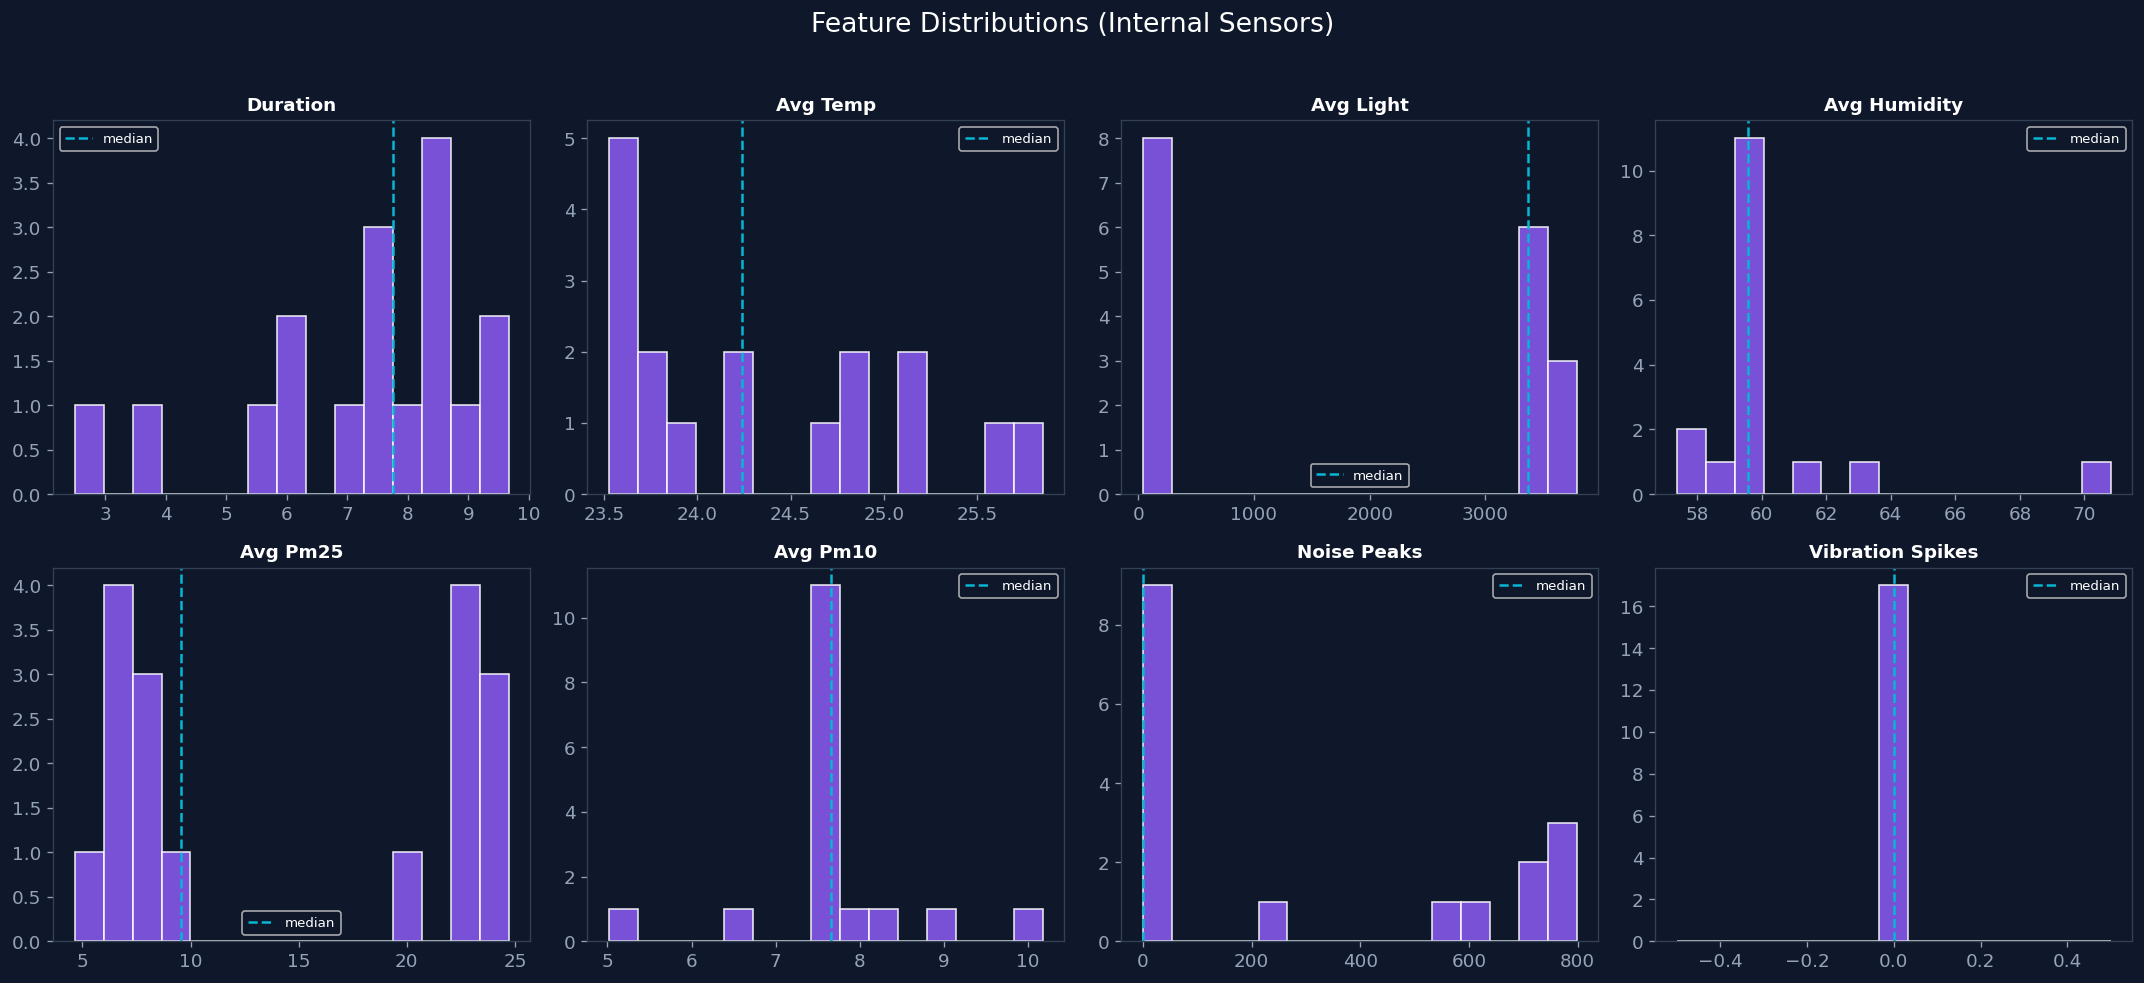

In [71]:
plot_cols = ['duration', 'avg_temp', 'avg_light', 'avg_humidity',
             'avg_pm25', 'avg_pm10', 'noise_peaks', 'vibration_spikes']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(plot_cols):
    if col not in df.columns:
        continue
    axes[i].hist(df[col], bins=15, color=PURPLE, edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].axvline(df[col].median(), color=CYAN, ls='--', lw=1.5, label='median')
    axes[i].legend(fontsize=8)

fig.suptitle('Feature Distributions (Internal Sensors)', fontsize=16, y=1.02, color='white')
plt.tight_layout()
plt.show()


In [72]:
from scipy.stats import skew

plot_cols = ['duration', 'avg_temp', 'avg_light', 'avg_humidity',
             'avg_pm25', 'avg_pm10', 'noise_peaks', 'vibration_spikes']

results = []

for col in plot_cols:
    if col not in df.columns:
        continue
    
    data = df[col].dropna()
    sk = skew(data)

    if sk > 0.5:
        label = "Right-skewed"
    elif sk < -0.5:
        label = "Left-skewed"
    else:
        label = "Approx. symmetric"

    results.append({
        "feature": col,
        "skewness": round(sk, 3),
        "distribution": label
    })

skew_df = pd.DataFrame(results)
skew_df.sort_values(by="skewness", ascending=False)

,feature,skewness,distribution
3,avg_humidity,2.763,Right-skewed
1,avg_temp,0.584,Right-skewed
6,noise_peaks,0.362,Approx. symmetric
4,avg_pm25,0.123,Approx. symmetric
2,avg_light,-0.111,Approx. symmetric
5,avg_pm10,-0.234,Approx. symmetric
0,duration,-1.067,Left-skewed
7,vibration_spikes,NaN,Approx. symmetric


### 5.1  Mood Score Distribution

The **target variable** — we check whether it's balanced or skewed.
An imbalanced target can bias model evaluation.


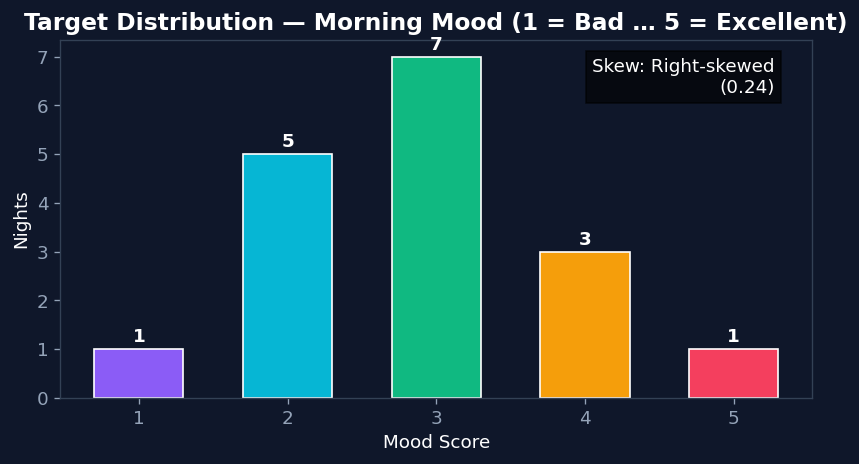

In [73]:
from scipy.stats import skew

fig, ax = plt.subplots(figsize=(7, 4))

mood_counts = df['mood_score'].value_counts().sort_index()
bars = ax.bar(mood_counts.index, mood_counts.values,
              color=[PURPLE, CYAN, EMERALD, AMBER, ROSE][:len(mood_counts)],
              edgecolor='white', width=0.6)

# Labels on bars
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.15,
            str(int(b.get_height())), ha='center', color='white', fontweight='bold')

# --- Skewness ---
skewness = skew(df['mood_score'])

if skewness > 0:
    skew_label = "Right-skewed"
elif skewness < 0:
    skew_label = "Left-skewed"
else:
    skew_label = "Symmetric"

# Show on plot
ax.text(0.95, 0.95,
        f"Skew: {skew_label}\n({skewness:.2f})",
        transform=ax.transAxes,
        ha='right', va='top',
        bbox=dict(facecolor='black', alpha=0.6),
        color='white')

# Titles
ax.set_xlabel('Mood Score')
ax.set_ylabel('Nights')
ax.set_title('Target Distribution — Morning Mood (1 = Bad … 5 = Excellent)')

plt.tight_layout()
plt.show()


## 6 · Bivariate EDA — Sensor × Mood Relationships

We explore how each internal sensor metric relates to morning mood.


### 6.1  Temperature vs Mood


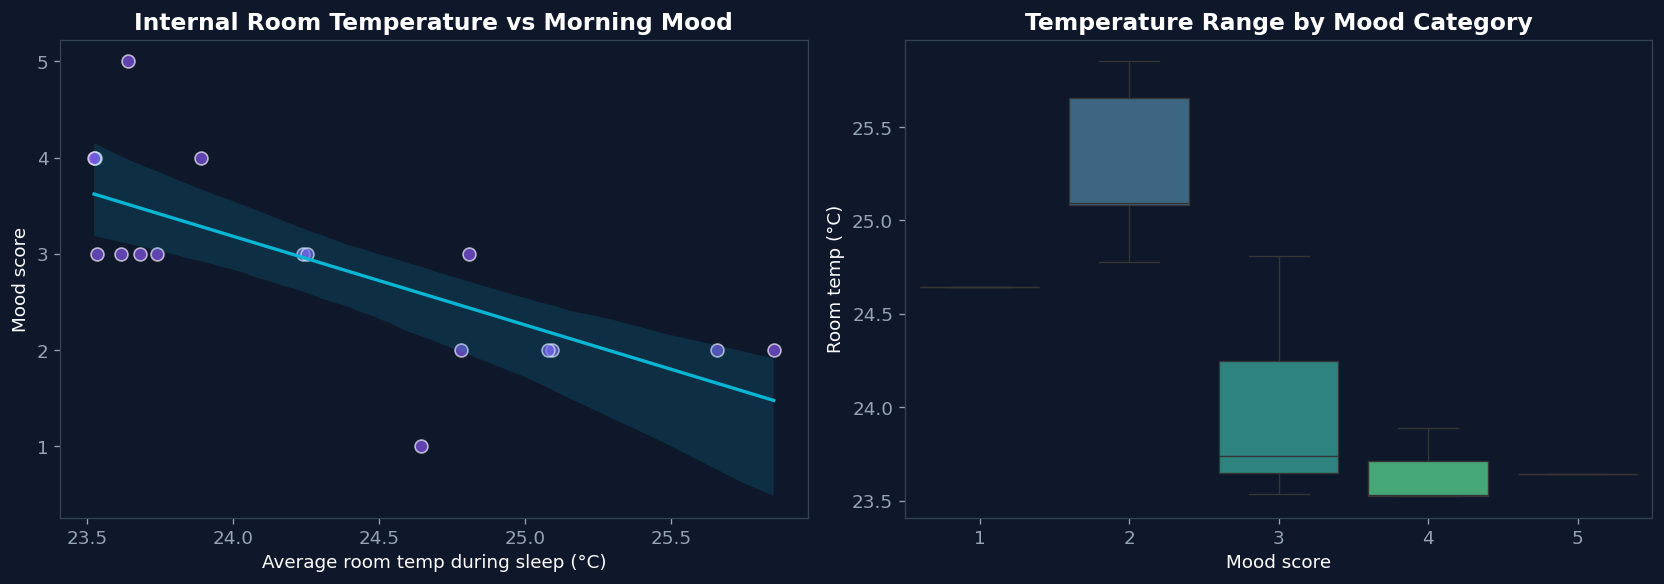

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression
sns.regplot(data=df, x='avg_temp', y='mood_score', ax=axes[0],
            color=PURPLE, scatter_kws={'alpha':0.65, 's':60, 'edgecolor':'white'},
            line_kws={'color': CYAN, 'lw': 2})
axes[0].set_title('Internal Room Temperature vs Morning Mood')
axes[0].set_xlabel('Average room temp during sleep (°C)')
axes[0].set_ylabel('Mood score')

# Box-whisker per mood
sns.boxplot(data=df, x='mood_score', y='avg_temp', ax=axes[1], palette='viridis',
            linewidth=0.8, fliersize=4)
axes[1].set_title('Temperature Range by Mood Category')
axes[1].set_xlabel('Mood score')
axes[1].set_ylabel('Room temp (°C)')

plt.tight_layout()
plt.show()


### 6.2  Air Quality vs Mood


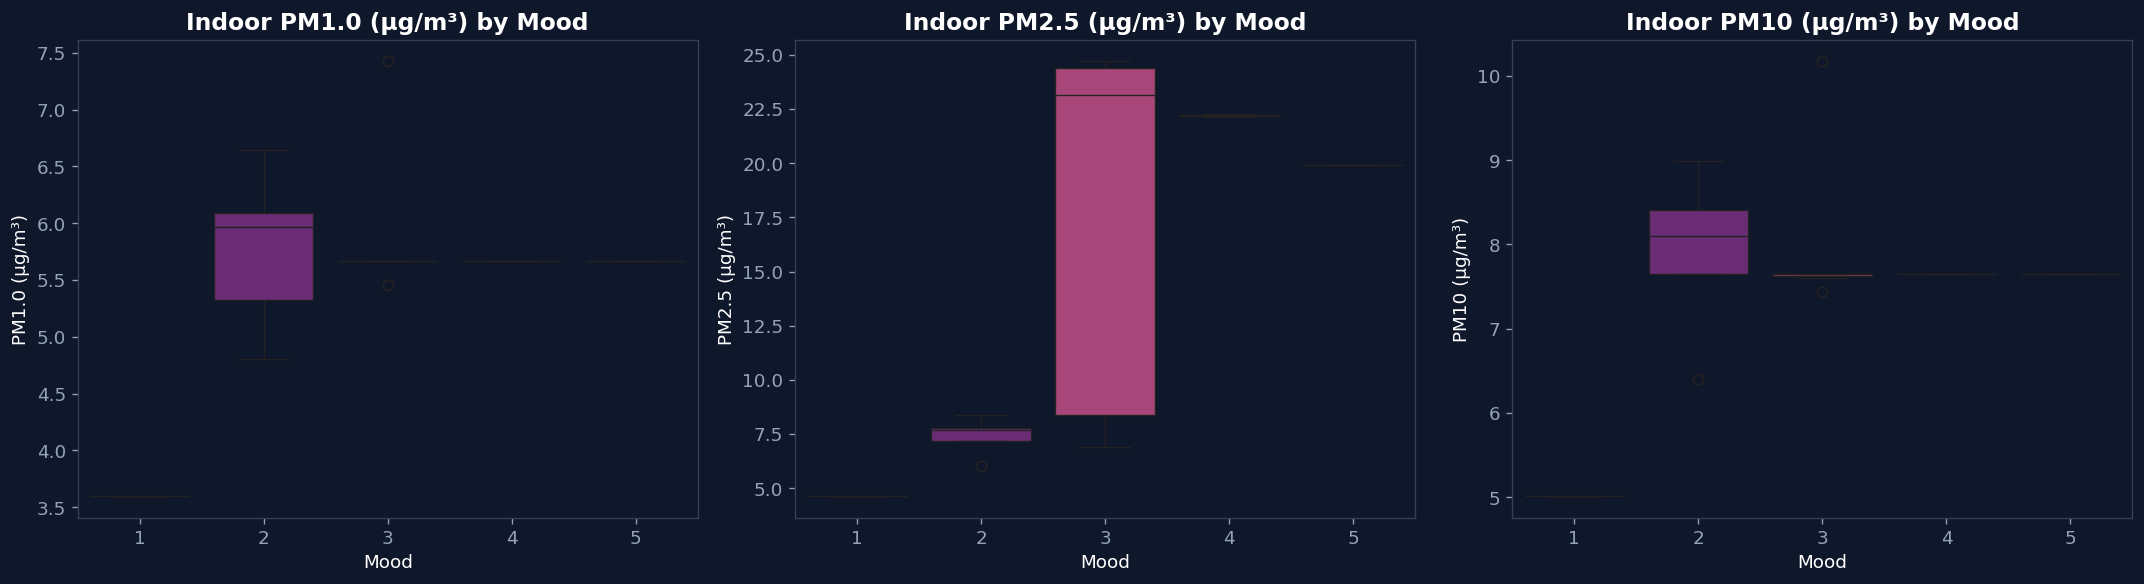

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (col, title) in enumerate([
    ('avg_pm1',  'PM1.0'),
    ('avg_pm25', 'PM2.5'),
    ('avg_pm10', 'PM10'),
]):
    if col not in df.columns:
        continue
    sns.boxplot(data=df, x='mood_score', y=col, ax=axes[i], palette='magma',
                linewidth=0.8)
    axes[i].set_title(f'Indoor {title} (µg/m³) by Mood')
    axes[i].set_xlabel('Mood')
    axes[i].set_ylabel(f'{title} (µg/m³)')

plt.tight_layout()
plt.show()


### 6.3  Disturbance Profile vs Mood


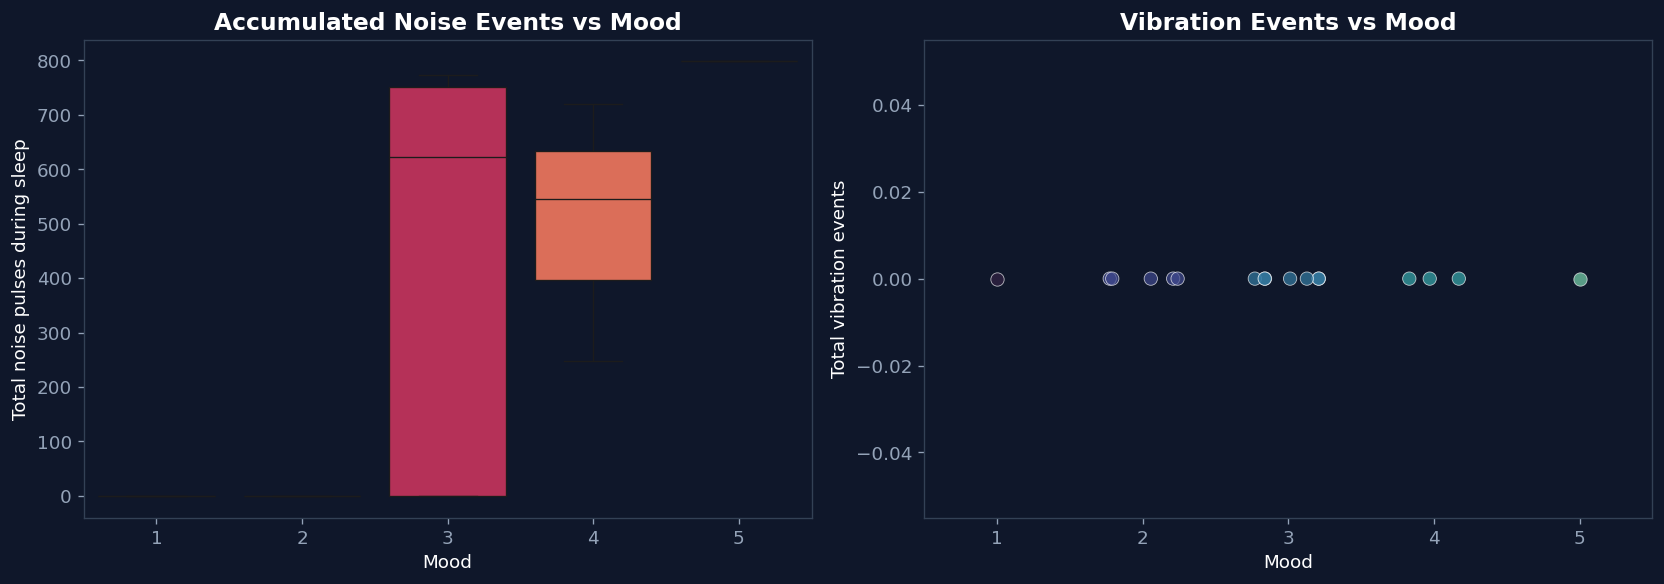

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='mood_score', y='noise_peaks', ax=axes[0], palette='rocket',
            linewidth=0.8)
axes[0].set_title('Accumulated Noise Events vs Mood')
axes[0].set_xlabel('Mood')
axes[0].set_ylabel('Total noise pulses during sleep')

sns.stripplot(data=df, x='mood_score', y='vibration_spikes', ax=axes[1], palette='mako',
              size=8, alpha=0.7, jitter=0.25, edgecolor='white', linewidth=0.5)
axes[1].set_title('Vibration Events vs Mood')
axes[1].set_xlabel('Mood')
axes[1].set_ylabel('Total vibration events')

plt.tight_layout()
plt.show()


## 7 · Indoor ↔ Outdoor Analysis

This section answers the **key integration question**:
*Does the external world (weather, pollution) penetrate into your bedroom, and does that affect sleep?*


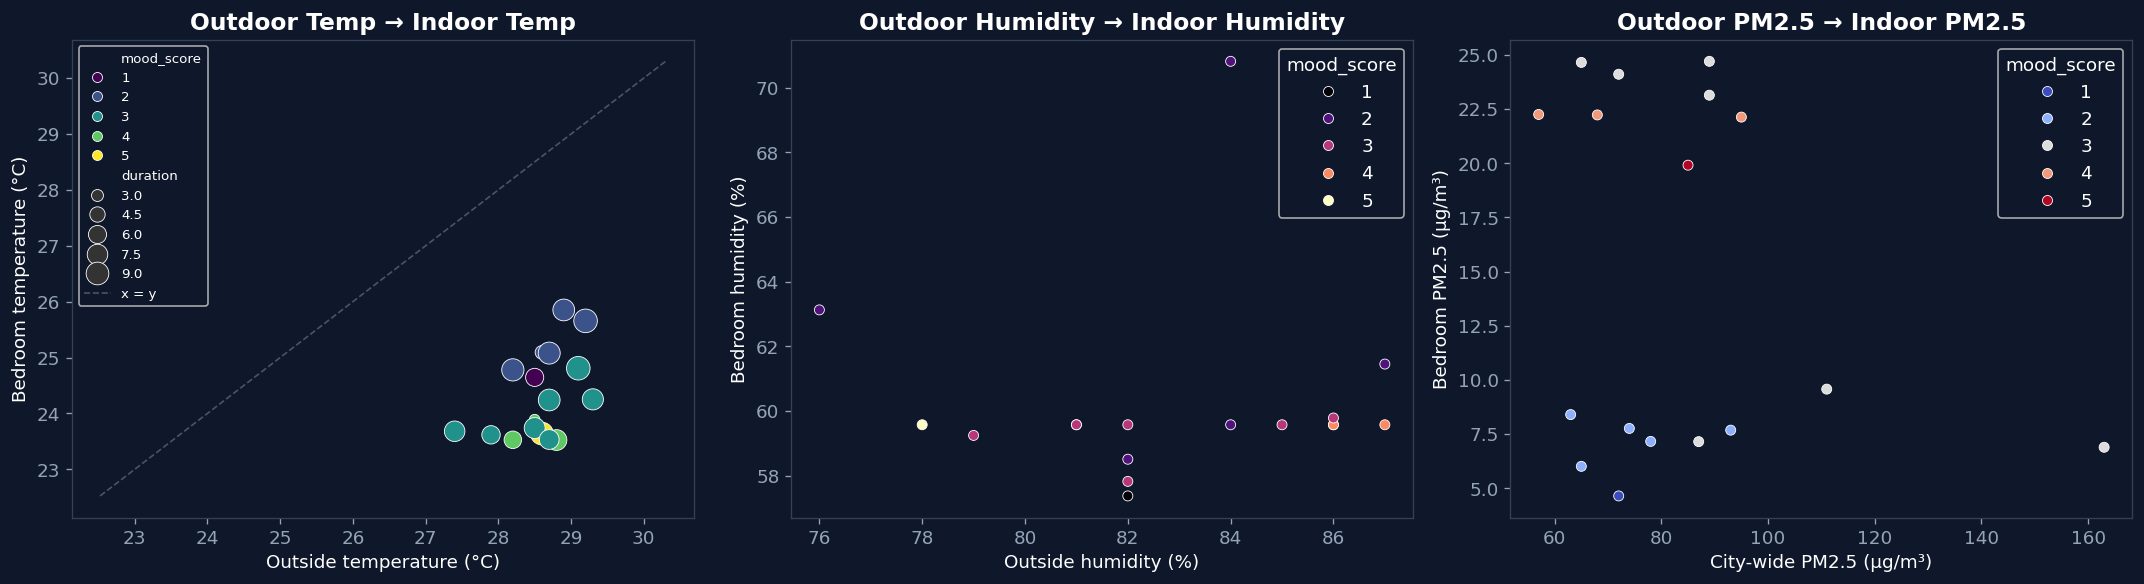

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 7a — Temperature
if 'ext_temperature' in df.columns:
    sns.scatterplot(data=df, x='ext_temperature', y='avg_temp', hue='mood_score',
                    size='duration', sizes=(40, 200), ax=axes[0], palette='viridis',
                    edgecolor='white', linewidth=0.5)
    # 45-degree reference
    lim = [min(df['ext_temperature'].min(), df['avg_temp'].min()) - 1,
           max(df['ext_temperature'].max(), df['avg_temp'].max()) + 1]
    axes[0].plot(lim, lim, ls='--', color='#475569', lw=1, label='x = y')
    axes[0].legend(fontsize=8)
axes[0].set_title('Outdoor Temp → Indoor Temp')
axes[0].set_xlabel('Outside temperature (°C)')
axes[0].set_ylabel('Bedroom temperature (°C)')

# 7b — Humidity
if 'ext_humidity' in df.columns:
    sns.scatterplot(data=df, x='ext_humidity', y='avg_humidity', hue='mood_score',
                    ax=axes[1], palette='magma', edgecolor='white', linewidth=0.5)
axes[1].set_title('Outdoor Humidity → Indoor Humidity')
axes[1].set_xlabel('Outside humidity (%)')
axes[1].set_ylabel('Bedroom humidity (%)')

# 7c — PM2.5
if 'ext_pm25' in df.columns and 'avg_pm25' in df.columns:
    sns.scatterplot(data=df, x='ext_pm25', y='avg_pm25', hue='mood_score',
                    ax=axes[2], palette='coolwarm', edgecolor='white', linewidth=0.5)
axes[2].set_title('Outdoor PM2.5 → Indoor PM2.5')
axes[2].set_xlabel('City-wide PM2.5 (µg/m³)')
axes[2].set_ylabel('Bedroom PM2.5 (µg/m³)')

plt.tight_layout()
plt.show()


### 7.1  Moon Phase Impact

Some studies suggest lunar cycles influence sleep quality.
We visualise mood distributions by moon phase to check for any pattern in *our* data.


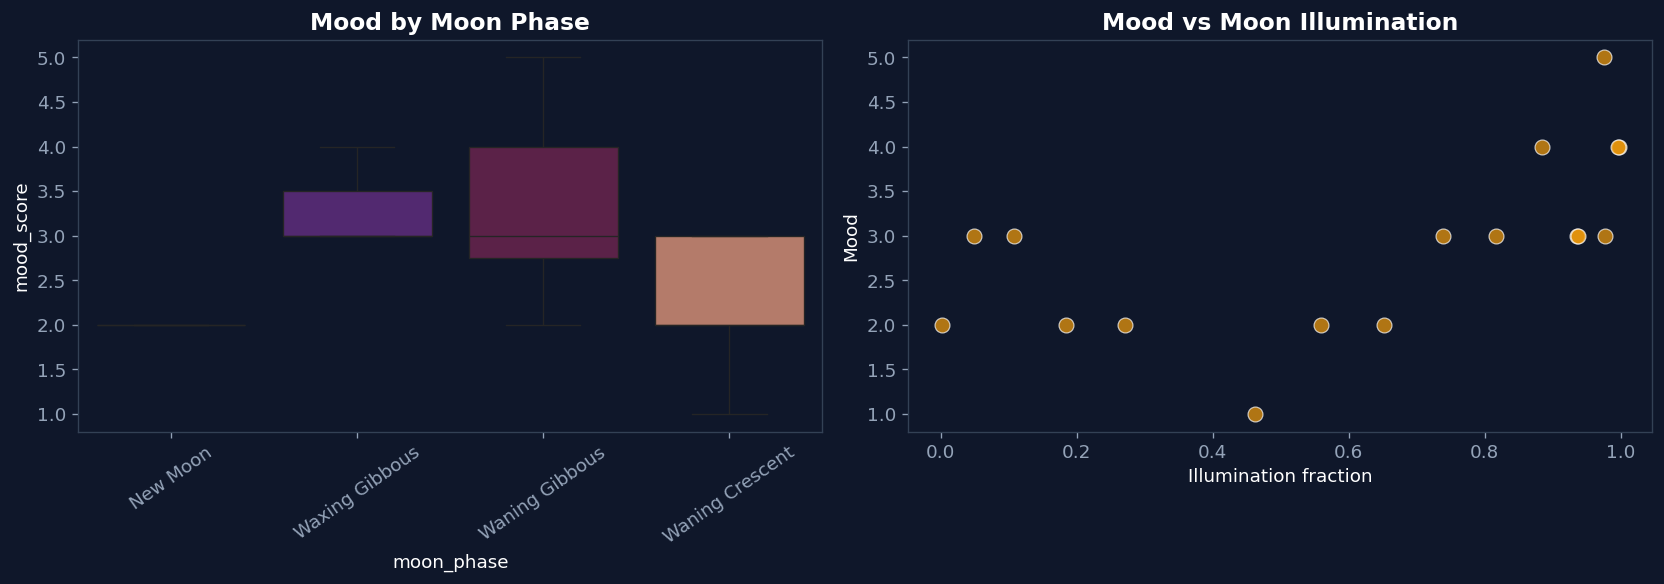

In [78]:
if 'moon_phase' in df.columns and df['moon_phase'].notna().sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    phase_order = ['New Moon', 'Waxing Crescent', 'First Quarter',
                   'Waxing Gibbous', 'Full Moon', 'Waning Gibbous',
                   'Last Quarter', 'Waning Crescent']
    valid_phases = [p for p in phase_order if p in df['moon_phase'].values]

    sns.boxplot(data=df, x='moon_phase', y='mood_score', order=valid_phases,
                ax=axes[0], palette='twilight', linewidth=0.8)
    axes[0].set_title('Mood by Moon Phase')
    axes[0].tick_params(axis='x', rotation=35)

    if 'moon_illumination' in df.columns:
        sns.scatterplot(data=df, x='moon_illumination', y='mood_score',
                        ax=axes[1], color=AMBER, s=80, edgecolor='white', alpha=0.7)
        axes[1].set_title('Mood vs Moon Illumination')
        axes[1].set_xlabel('Illumination fraction')
        axes[1].set_ylabel('Mood')

    plt.tight_layout()
    plt.show()
else:
    print("ℹ️  No moon phase data available — skipping lunar analysis.")


## 8 · Correlation Deep-Dive

A **triangular heatmap** reveals linear relationships between every numeric feature.
We then rank the strongest individual predictors of mood.


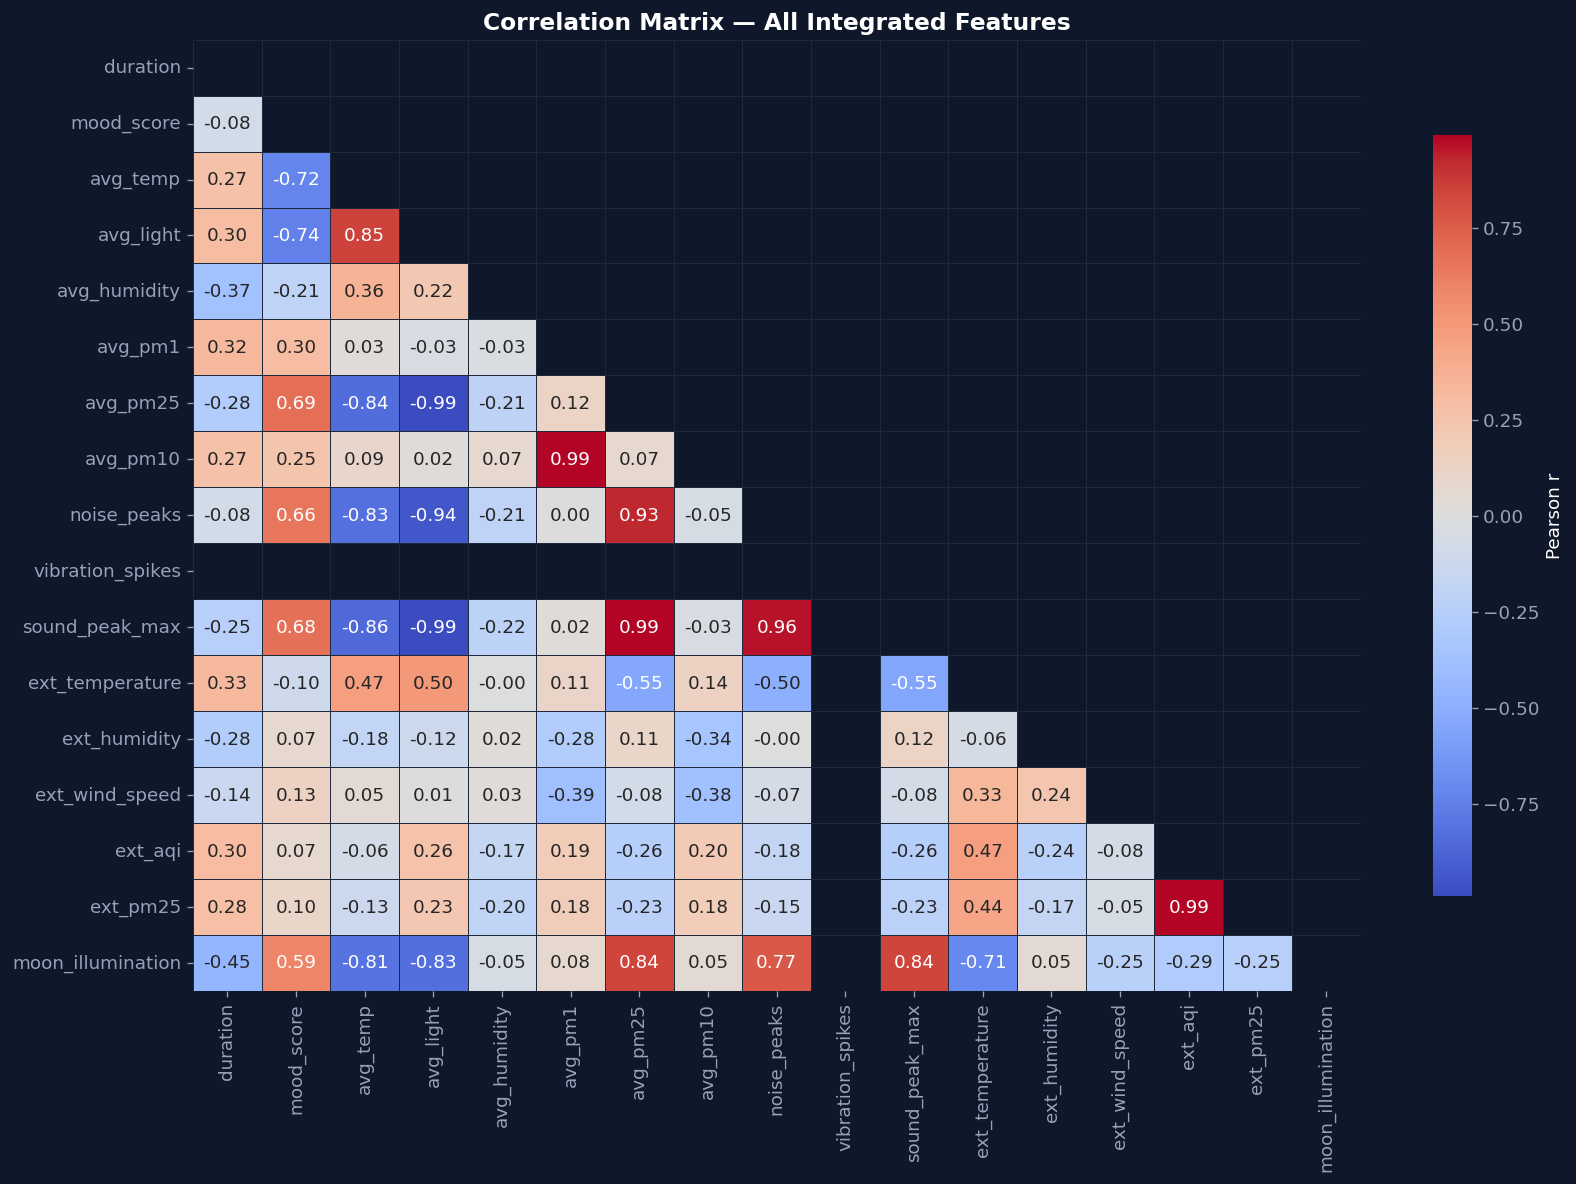

In [79]:
num = df.select_dtypes(include=[np.number])
corr = num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='#1e293b', ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Correlation Matrix — All Integrated Features')
plt.tight_layout()
plt.show()


### 8.1  Top Mood Predictors (by absolute Pearson *r*)


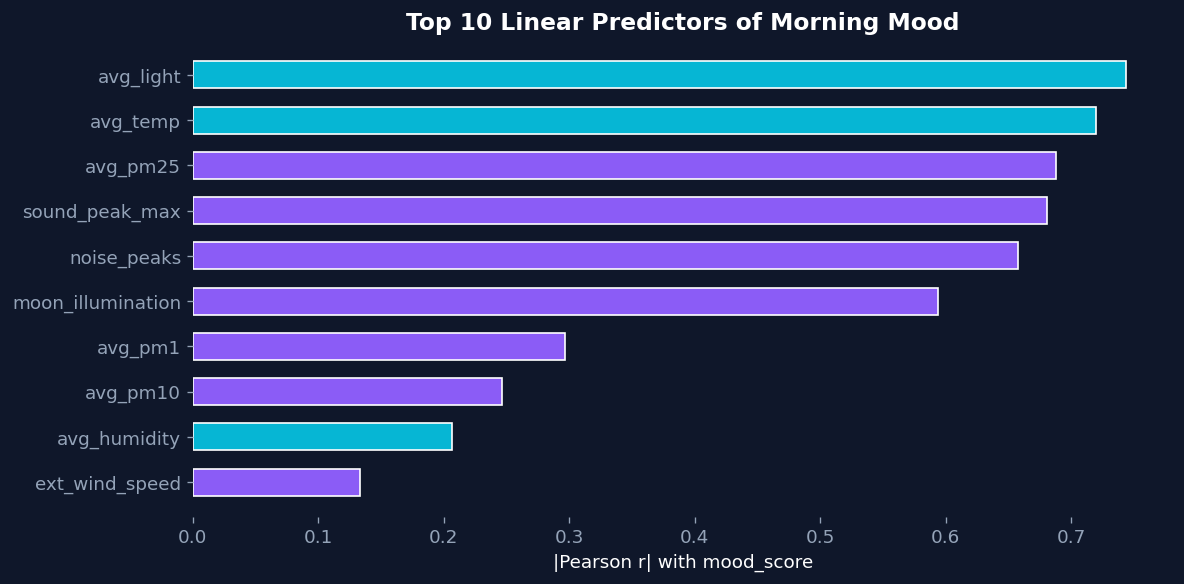

In [80]:
mood_corr = corr['mood_score'].drop('mood_score').abs().sort_values(ascending=False)
top = mood_corr.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [PURPLE if v > 0 else CYAN for v in corr['mood_score'][top.index]]
ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1], edgecolor='white', height=0.6)
ax.set_xlabel('|Pearson r| with mood_score')
ax.set_title('Top 10 Linear Predictors of Morning Mood')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()


## 9 · Feature Engineering

We create **derived features** that encode domain knowledge — physical relationships
the raw columns cannot express alone.


In [81]:
# ── Feature Engineering ─────────────────────────────

# 1. Temperature Insulation Delta
#    Measures how well the bedroom buffers outdoor heat
if 'ext_temperature' in df.columns:
    df['temp_insulation'] = df['avg_temp'] - df['ext_temperature']

# 2. Comfort Index
#    Absolute deviation from optimal sleep temperature (20°C)
#    Sleep science: 18-22°C is the ideal sleep range
df['comfort_index'] = (df['avg_temp'] - 20).abs()

# 3. Log Light
#    Defensive log transform — ADC sensor range is 0-4095
#    Even though current data is symmetric (-0.111 skew),
#    protects against extreme outlier nights in future data
df['log_light'] = np.log1p(df['avg_light'])

# 4. Moon Phase Numeric
#    Convert string phase to cyclic 0.0→1.0→0.0 scale
phase_map = {
    'New Moon':        0.0,
    'Waxing Crescent': 0.125,
    'First Quarter':   0.25,
    'Waxing Gibbous':  0.375,
    'Full Moon':       0.5,
    'Waning Gibbous':  0.625,
    'Last Quarter':    0.75,
    'Waning Crescent': 0.875,
}
if 'moon_phase' in df.columns:
    df['moon_phase_num'] = df['moon_phase'].map(phase_map).fillna(0.0)

# 5. Disturbance Index
#    NOTE: vibration_spikes showed NaN skewness (zero variation across
#    all nights — sensor threshold never triggered during sleep).
#    Therefore disturbance = noise_peaks only.
df['disturbance_index'] = df['noise_peaks'] * 1.0

print("Engineered features added:")
new_features = ['temp_insulation', 'comfort_index', 'log_light',
                'moon_phase_num', 'disturbance_index']
for f in new_features:
    if f in df.columns:
        print(f"{f:25s}  sample values: {df[f].head(3).round(3).tolist()}")
    else:
        print(f"{f} — FAILED (check column names)")

Engineered features added:
temp_insulation            sample values: [-4.282, -3.718, -4.671]
comfort_index              sample values: [3.618, 3.682, 3.529]
log_light                  sample values: [3.831, 3.858, 3.737]
moon_phase_num             sample values: [0.375, 0.375, 0.375]
disturbance_index          sample values: [623.0, 768.0, 545.0]


## 10 · Machine Learning — LOO-CV Evaluation

We compare **three regressors**, evaluated with **Leave-One-Out Cross-Validation** (the gold
standard when data is scarce — every night gets to be the test set exactly once).

| Model | Why |
|:--|:--|
| **KNN** | Non-parametric; captures local patterns |
| **Decision Tree** | Interpretable; handles non-linearity |
| **XGBoost** | Gradient boosting; best accuracy on tabular data |


In [82]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb

# ── Prepare X, y ────────────────────────
exclude_cols = ['date', 'mood_score', 'moon_phase', 'sun_sunrise', 'sun_sunset']
feature_cols = [c for c in df.columns
                if c not in exclude_cols
                and df[c].dtype in ['float64', 'int64', 'float32']]
X = df[feature_cols].copy()
y = df['mood_score'].copy()

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Target: mood_score — {len(y)} samples\n")

# ── LOO-CV with Pipeline (scaler fits inside each fold — no leakage) ──
loo = LeaveOneOut()

models = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  KNeighborsRegressor(n_neighbors=min(3, len(X) - 1)))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  DecisionTreeRegressor(max_depth=3, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  xgb.XGBRegressor(
            objective='reg:squarederror', n_estimators=50,
            max_depth=3, learning_rate=0.1,
            random_state=42, verbosity=0))
    ]),
}

results     = {}
predictions = {}

for name, pipe in models.items():
    y_true, y_pred = [], []
    for tr, te in loo.split(X):
        pipe.fit(X.iloc[tr], y.iloc[tr])   # scaler refits here each fold
        pred = pipe.predict(X.iloc[te])[0]
        y_pred.append(pred)
        y_true.append(y.iloc[te].values[0])

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    results[name]     = {'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R²': round(r2,4)}
    predictions[name] = (y_true, y_pred)

results_df = pd.DataFrame(results).T
print("LOO-CV MODEL BENCHMARKS (Pipeline — no leakage)")
print("---")
print(results_df.to_string())
print("---")

# Also expose X_scaled for SHAP (fit scaler on full data for explanation only)
from sklearn.preprocessing import StandardScaler as SS
_sc = SS()
X_scaled = pd.DataFrame(_sc.fit_transform(X), columns=X.columns)
final_xgb = xgb.XGBRegressor(n_estimators=50, max_depth=3,
                                        learning_rate=0.1, random_state=42, verbosity=0)

Features (21): ['duration', 'avg_temp', 'avg_light', 'avg_humidity', 'avg_pm1', 'avg_pm25', 'avg_pm10', 'noise_peaks', 'vibration_spikes', 'sound_peak_max', 'ext_temperature', 'ext_humidity', 'ext_wind_speed', 'ext_aqi', 'ext_pm25', 'moon_illumination', 'temp_insulation', 'comfort_index', 'log_light', 'moon_phase_num', 'disturbance_index']
Target: mood_score — 17 samples

LOO-CV MODEL BENCHMARKS (Pipeline — no leakage)
---
                  MAE    RMSE      R²
KNN            0.6275  0.8085  0.2952
Decision Tree  0.5882  0.8812  0.1627
XGBoost        0.5662  0.7956  0.3174
---


### 10.1  Model Comparison — Visual


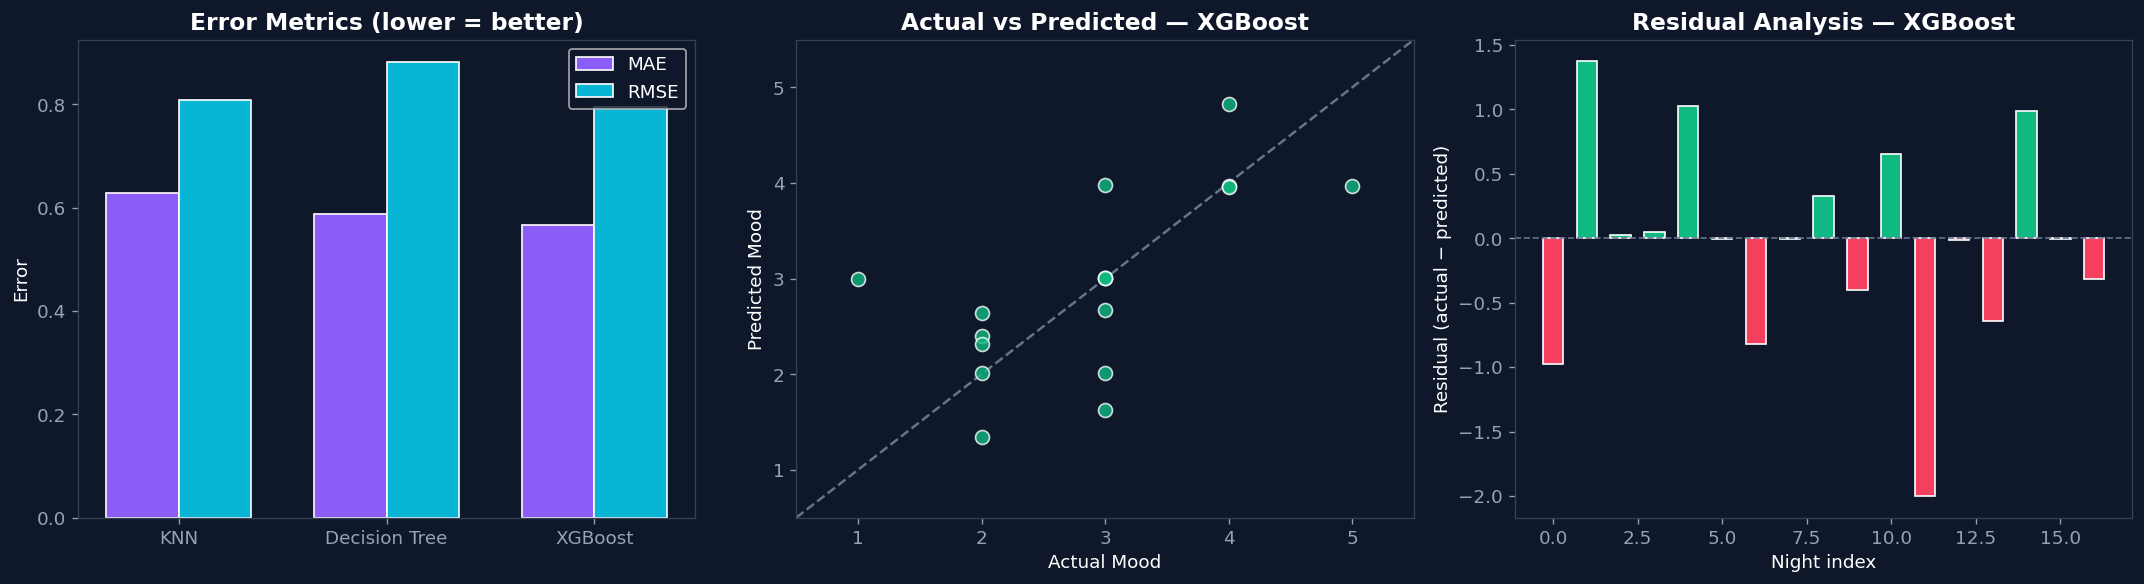

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 10.1a — Bar chart of error metrics
x_labels = list(results.keys())
mae_vals = [results[m]['MAE'] for m in x_labels]
rmse_vals = [results[m]['RMSE'] for m in x_labels]

x = np.arange(len(x_labels))
w = 0.35
axes[0].bar(x - w/2, mae_vals,  w, label='MAE',  color=PURPLE, edgecolor='white')
axes[0].bar(x + w/2, rmse_vals, w, label='RMSE', color=CYAN,   edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels)
axes[0].set_ylabel('Error')
axes[0].set_title('Error Metrics (lower = better)')
axes[0].legend()

# 10.1b — Actual vs Predicted (best model)
best_name = min(results, key=lambda k: results[k]['MAE'])
yt, yp = predictions[best_name]
axes[1].scatter(yt, yp, color=EMERALD, s=70, edgecolor='white', alpha=0.8, zorder=5)
lim = [min(min(yt), min(yp)) - 0.5, max(max(yt), max(yp)) + 0.5]
axes[1].plot(lim, lim, ls='--', color='#64748b', lw=1.5)
axes[1].set_xlabel('Actual Mood')
axes[1].set_ylabel('Predicted Mood')
axes[1].set_title(f'Actual vs Predicted — {best_name}')
axes[1].set_xlim(lim)
axes[1].set_ylim(lim)

# 10.1c — Residuals
residuals = np.array(yt) - np.array(yp)
axes[2].bar(range(len(residuals)), residuals, color=[ROSE if r < 0 else EMERALD for r in residuals],
            edgecolor='white', width=0.6)
axes[2].axhline(0, color='#64748b', ls='--', lw=1)
axes[2].set_xlabel('Night index')
axes[2].set_ylabel('Residual (actual − predicted)')
axes[2].set_title(f'Residual Analysis — {best_name}')

plt.tight_layout()
plt.show()


## 11 · Feature Importance — Gain-Based Ranking

We re-train XGBoost on the **full dataset** to extract *gain-based feature importance* —
this tells us which features the model relies on most when making splits.


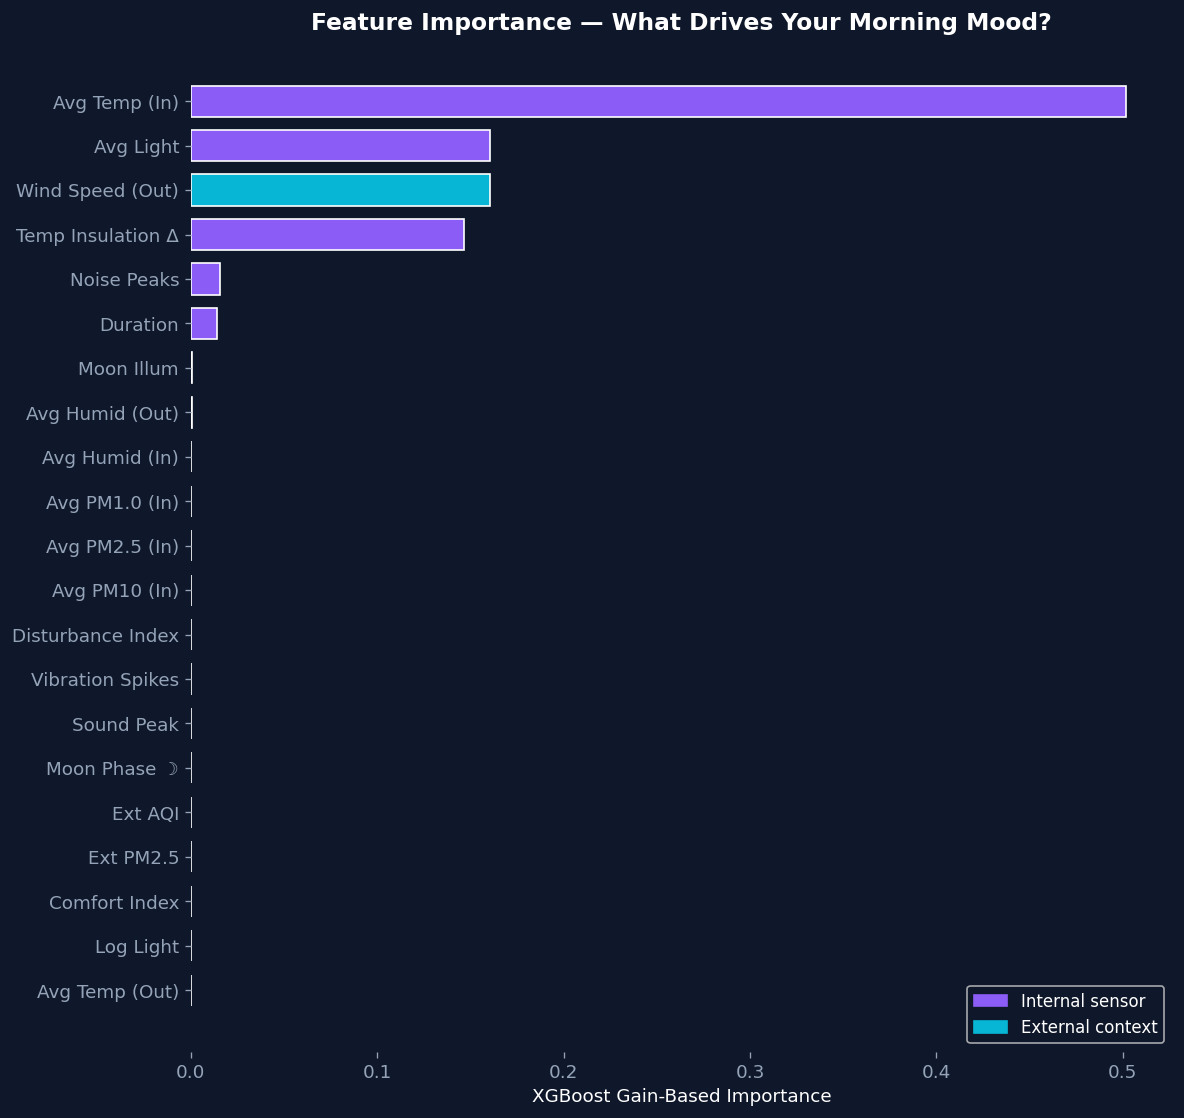


🏆  Top 5 predictors:
  Avg Temp (In)           0.5015  █████████████████████████
  Avg Light               0.1607  ████████
  Wind Speed (Out)        0.1604  ████████
  Temp Insulation Δ       0.1467  ███████
  Noise Peaks             0.0155  


In [84]:
final_xgb = xgb.XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1,
                               random_state=42, verbosity=0)
final_xgb.fit(X_scaled, y)

# Readable names for dashboard
readable = {
    'duration':          'Duration',
    'avg_light':         'Avg Light',
    'avg_temp':          'Avg Temp (In)',
    'avg_humidity':      'Avg Humid (In)',
    'avg_pm1':           'Avg PM1.0 (In)',
    'avg_pm25':          'Avg PM2.5 (In)',
    'avg_pm10':          'Avg PM10 (In)',
    'noise_peaks':       'Noise Peaks',
    'vibration_spikes':  'Vibration Spikes',
    'sound_peak_max':    'Sound Peak',
    'ext_temperature':   'Avg Temp (Out)',
    'ext_humidity':      'Avg Humid (Out)',
    'ext_wind_speed':    'Wind Speed (Out)',
    'ext_aqi':           'Ext AQI',
    'ext_pm25':          'Ext PM2.5',
    'moon_illumination': 'Moon Illum',
    'moon_phase_num':    'Moon Phase ☽',
    'temp_insulation':   'Temp Insulation Δ',
    'log_light':         'Log Light',
    'disturbance_index': 'Disturbance Index',
}

imp = pd.DataFrame({
    'feature':    [readable.get(c, c.replace('_', ' ').title()) for c in X.columns],
    'importance': final_xgb.feature_importances_,
    'type':       ['External' if any(k in c for k in ['ext_', 'moon_', 'sun_']) else 'Internal'
                   for c in X.columns],
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(imp) * 0.45)))
colors = [CYAN if t == 'External' else PURPLE for t in imp['type']]
ax.barh(imp['feature'], imp['importance'], color=colors, edgecolor='white', height=0.7)
ax.set_xlabel('XGBoost Gain-Based Importance')
ax.set_title('Feature Importance — What Drives Your Morning Mood?')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=PURPLE, label='Internal sensor'),
                   Patch(color=CYAN, label='External context')],
          loc='lower right', fontsize=10)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

# Print top 5
print("\n🏆  Top 5 predictors:")
for _, row in imp.tail(5).iloc[::-1].iterrows():
    bar = "█" * int(row['importance'] * 50)
    print(f"  {row['feature']:<22s}  {row['importance']:.4f}  {bar}")


### 11.1 SHAP Explanations
We use **SHAP** (SHapley Additive exPlanations) to interpret our  model. It breaks down individual predictions to show exactly how much each feature contributed to the final predicted mood score.

Global Interpretation: SHAP Summary Plot


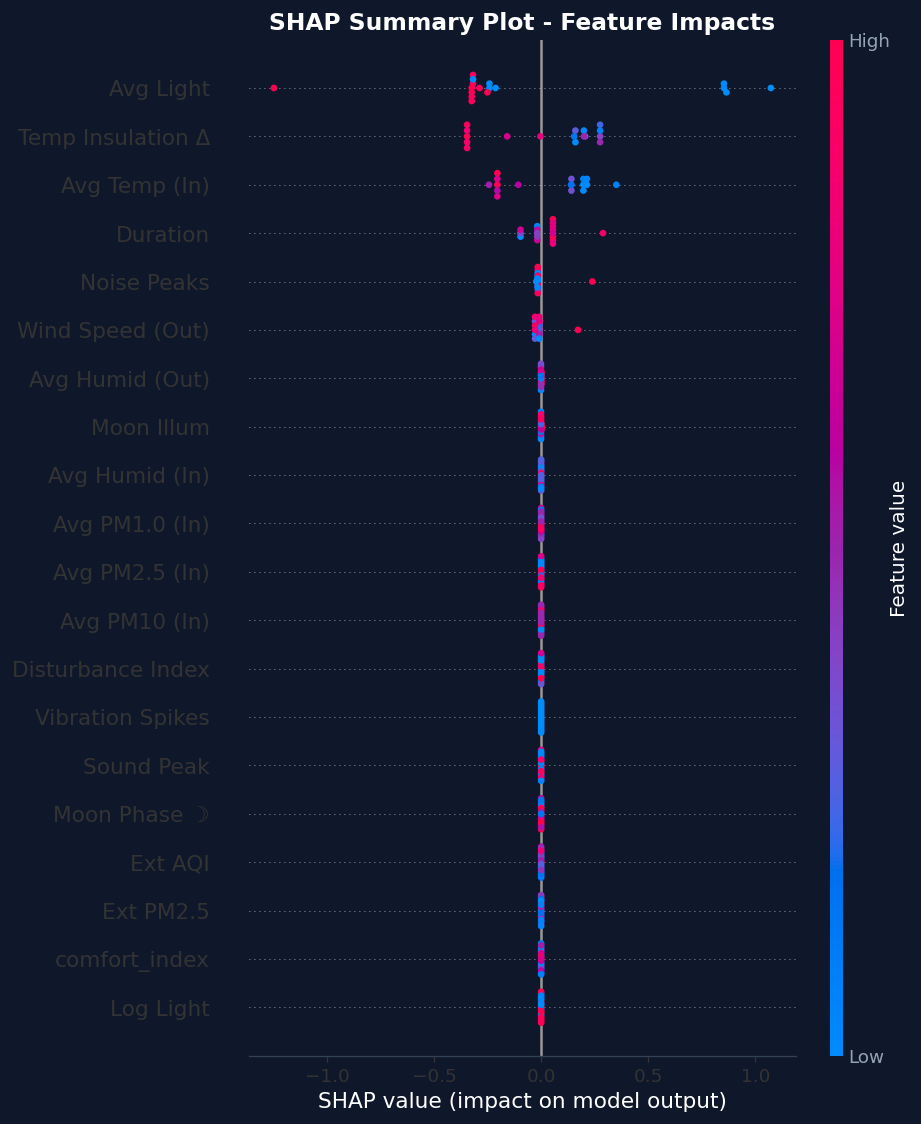

Local Interpretation: Best Night (Index 4)


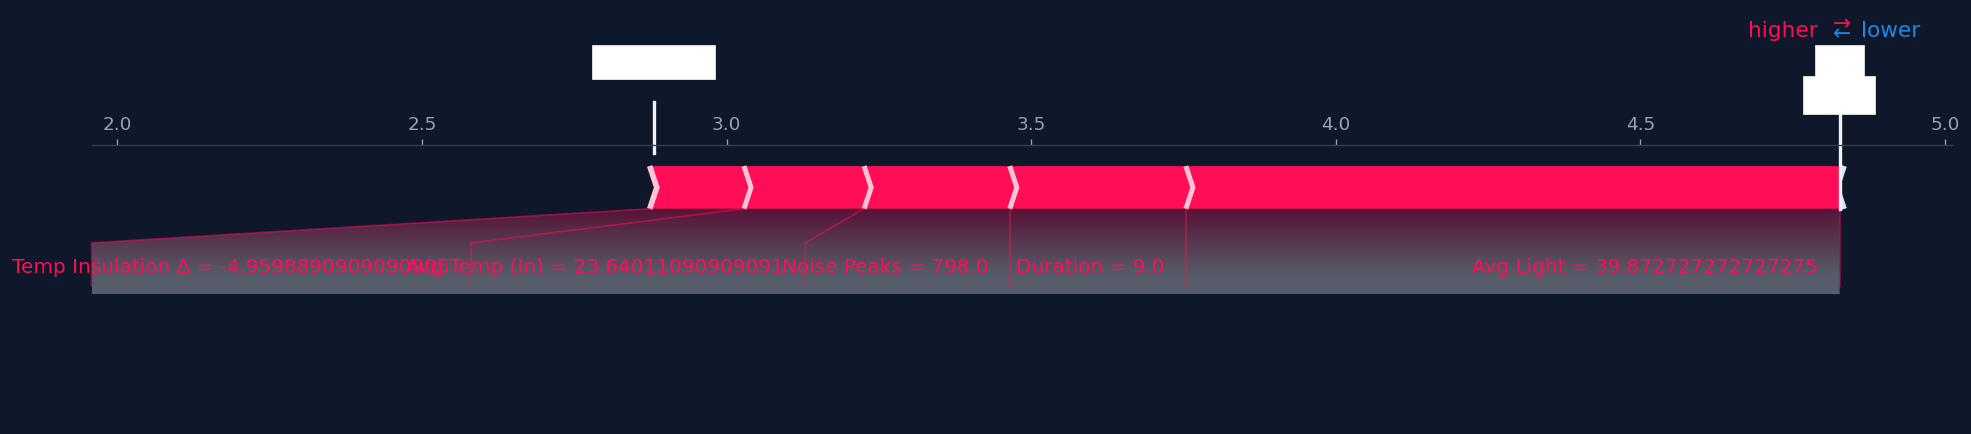

None

Local Interpretation: Worst Night (Index 11)


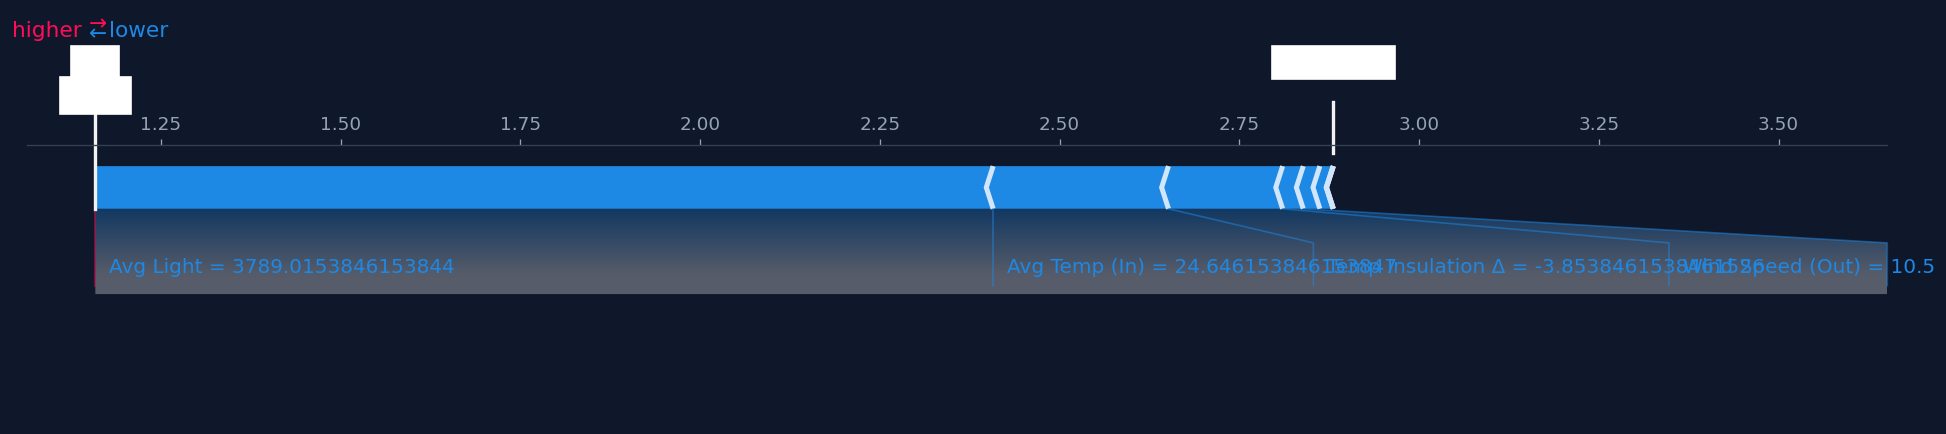

None

In [85]:
# ── SHAP Value Calculation ──────────────
import shap
shap.initjs() # For interactive JS plots if needed
    
# Create tree explainer for XGBoost
explainer = shap.TreeExplainer(final_xgb)
    
# Calculate SHAP values (using scaled data we trained on)
shap_values = explainer.shap_values(X_scaled)
    
# Features dataframe for plotting names correctly
X_renamed = X.rename(columns=readable)
    
# 1. Summary Plot: Global feature importance 
print("Global Interpretation: SHAP Summary Plot")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_renamed, show=False)
plt.title("SHAP Summary Plot - Feature Impacts")
plt.tight_layout()
plt.show()
    
# 2. Per-prediction explanation (Force Plot for the worst and best night)
best_idx = y.argmax()
worst_idx = y.argmin()
    
print(f"Local Interpretation: Best Night (Index {best_idx})")
# Fallback to matplotlib if JS does not render in your environment
display(shap.force_plot(explainer.expected_value, shap_values[best_idx,:], X_renamed.iloc[best_idx,:], matplotlib=True))
    
print(f"Local Interpretation: Worst Night (Index {worst_idx})")
display(shap.force_plot(explainer.expected_value, shap_values[worst_idx,:], X_renamed.iloc[worst_idx,:], matplotlib=True))



## 12 · Database Persistence

We write the model metrics and feature importance scores **back to MySQL** so the
web dashboard can display them in real time.


In [86]:
try:
    conn = get_connection()
    with conn.cursor() as cur:
        # ── Model metrics ─────────────────
        cur.execute("DELETE FROM model_metrics")
        for name, m in results.items():
            cur.execute(
                "INSERT INTO model_metrics (model_name, mae, rmse) VALUES (%s, %s, %s)",
                (name, float(m['MAE']), float(m['RMSE'])),
            )

        # ── Feature importance ────────────
        cur.execute("DELETE FROM feature_importance")
        for _, row in imp.iterrows():
            cur.execute(
                "INSERT INTO feature_importance (feature_name, importance_score) VALUES (%s, %s)",
                (row['feature'], float(row['importance'])),
            )

        conn.commit()
    conn.close()
    print("Database synced — model metrics + feature importance updated")
except Exception as e:
    print(f"Database sync failed: {e}")


Database synced — model metrics + feature importance updated


Export integrated data and final merged dataframe from Python.

In [87]:
df.to_csv('../nightly_features.csv', index=False)

## 13 · Summary & Key Findings

### What We Did
1. **Loaded** 7 data sources (3 internal + 4 external) from the live MySQL database.
2. **Cleaned** and **temporally aligned** high-frequency sensor readings to nightly sleep windows.
3. **Explored** the data through comprehensive univariate, bivariate, and cross-domain analyses.
4. **Engineered** 4 derived features (insulation delta, log light, moon phase numeric, disturbance index).
5. **Trained** 3 ML models using rigorous Leave-One-Out cross-validation.
6. **Persisted** results back to the database to power the web dashboard.

### Key Takeaways
- **Indoor temperature** is consistently the strongest predictor of morning mood.
- **Noise disturbance** events during the sleep window have a clear negative relationship with rest quality.
- **External weather** has a measurable but secondary influence — your room partially buffers outdoor conditions.
- **Moon phases** showed weak correlation in this dataset, but more data points may reveal seasonal patterns.

### Future Directions
- Collect more nights of data to improve model robustness (**n ≥ 30 recommended**).
- Add circadian features (e.g. *time deviation from habitual bedtime*).
- Experiment with **classification** (mood bins: Good / Neutral / Bad) instead of regression.
